In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import requests
import random
import time

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: Tesla T4


In [2]:
url = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
response = requests.get(url)
text = response.text

print(f'Total characters: {len(text):,}')
print(f'Unique characters: {len(set(text))}')
print()
print('First 500 characters')
print(text[:500])

Total characters: 1,115,394
Unique characters: 65

First 500 characters
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


In [3]:
# Build character vocabulary
chars = sorted(set(text))
vocab_size = len(chars)
print(f'Vocabulary size: {vocab_size} unique characters')
print(f'Characters: {repr("".join(chars))}')

# Create mappings
char2idx = {ch: i for i, ch in enumerate(chars)}
idx2char = {i: ch for i, ch in enumerate(chars)}

# Encode full text as integers
encoded = np.array([char2idx[c] for c in text], dtype=np.int64)
print(f'\nEncoded shape: {encoded.shape}')
print(f'First 20 chars: {text[:20]!r}')
print(f'Encoded: {encoded[:20].tolist()}')

Vocabulary size: 65 unique characters
Characters: "\n !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"

Encoded shape: (1115394,)
First 20 chars: 'First Citizen:\nBefor'
Encoded: [18, 47, 56, 57, 58, 1, 15, 47, 58, 47, 64, 43, 52, 10, 0, 14, 43, 44, 53, 56]


In [4]:
SEQ_LEN = 100
BATCH_SIZE = 64

class CharDataset(torch.utils.data.Dataset):
    def __init__(self, data, seq_len):
        self.data = torch.tensor(data, dtype=torch.long)
        self.seq_len = seq_len

    def __len__(self):
        return len(self.data) - self.seq_len

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.seq_len]
        y = self.data[idx + 1 : idx + self.seq_len + 1]
        return x, y

split = int(0.9 * len(encoded))
train_ds  = CharDataset(encoded[:split], SEQ_LEN)
train_dl  = torch.utils.data.DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)

print(f'Training samples: {len(train_ds):,}')
print(f'Batches per epoch: {len(train_dl):,}')

xb, yb = next(iter(train_dl))
print(f'\nBatch X shape: {xb.shape}  (batch, seq_len)')
print(f'Batch Y shape: {yb.shape}')
print(f'\nSample input : {repr("".join(idx2char[i.item()] for i in xb[0][:30]))}')
print(f'Sample target: {repr("".join(idx2char[i.item()] for i in yb[0][:30]))}')

Training samples: 1,003,754
Batches per epoch: 15,684

Batch X shape: torch.Size([64, 100])  (batch, seq_len)
Batch Y shape: torch.Size([64, 100])

Sample input : 'a very pleasant thing\nindeed a'
Sample target: ' very pleasant thing\nindeed an'


In [5]:
class CharLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_size=256, num_layers=2, dropout=0.3):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(
            input_size = embed_dim,
            hidden_size = hidden_size,
            num_layers = num_layers,
            dropout = dropout,
            batch_first = True
        )
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        emb = self.embed(x)
        out, hidden = self.lstm(emb, hidden)
        out = self.drop(out)
        logits = self.fc(out)
        return logits, hidden

    def init_hidden(self, batch_size):
        h = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)
        c = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)
        return (h, c)


model = CharLSTM(vocab_size).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f'\nTotal parameters: {total_params:,}')

CharLSTM(
  (embed): Embedding(65, 128)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.3)
  (drop): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=65, bias=True)
)

Total parameters: 946,625


In [7]:
EPOCHS = 20
LR = 0.002

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

history = {'loss': []}

print(f'Training for {EPOCHS} epochs on {device}...')

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0
    t0 = time.time()

    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits, _ = model(xb)

        loss = criterion(logits.reshape(-1, vocab_size), yb.reshape(-1))
        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()

    scheduler.step()
    avg_loss = total_loss / len(train_dl)
    history['loss'].append(avg_loss)
    elapsed = time.time() - t0

    print(f'Epoch [{epoch:2d}/{EPOCHS}]  Loss: {avg_loss:.4f}  '
          f'Perplexity: {np.exp(avg_loss):.1f}  LR: {scheduler.get_last_lr()[0]:.5f}  '
          f'Time: {elapsed:.1f}s')

print('\nTraining complete!')

Training for 20 epochs on cuda...
Epoch [ 1/20]  Loss: 1.2568  Perplexity: 3.5  LR: 0.00200  Time: 320.6s
Epoch [ 2/20]  Loss: 1.2089  Perplexity: 3.3  LR: 0.00200  Time: 316.3s
Epoch [ 3/20]  Loss: 1.1983  Perplexity: 3.3  LR: 0.00200  Time: 316.3s
Epoch [ 4/20]  Loss: 1.1947  Perplexity: 3.3  LR: 0.00200  Time: 316.4s
Epoch [ 5/20]  Loss: 1.1937  Perplexity: 3.3  LR: 0.00100  Time: 316.3s
Epoch [ 6/20]  Loss: 1.1404  Perplexity: 3.1  LR: 0.00100  Time: 316.3s
Epoch [ 7/20]  Loss: 1.1213  Perplexity: 3.1  LR: 0.00100  Time: 316.3s
Epoch [ 8/20]  Loss: 1.1126  Perplexity: 3.0  LR: 0.00100  Time: 316.3s
Epoch [ 9/20]  Loss: 1.1068  Perplexity: 3.0  LR: 0.00100  Time: 316.6s
Epoch [10/20]  Loss: 1.1023  Perplexity: 3.0  LR: 0.00050  Time: 316.2s
Epoch [11/20]  Loss: 1.0718  Perplexity: 2.9  LR: 0.00050  Time: 316.2s
Epoch [12/20]  Loss: 1.0645  Perplexity: 2.9  LR: 0.00050  Time: 316.3s
Epoch [13/20]  Loss: 1.0609  Perplexity: 2.9  LR: 0.00050  Time: 316.3s
Epoch [14/20]  Loss: 1.0584  P

In [8]:
torch.save({
    'model_state_dict': model.state_dict(),
    'char2idx': char2idx,
    'idx2char': idx2char,
    'vocab_size': vocab_size,
    'history': history
}, 'char_lstm_shakespeare.pth')

print('Model saved to char_lstm_shakespeare.pth')

Model saved to char_lstm_shakespeare.pth


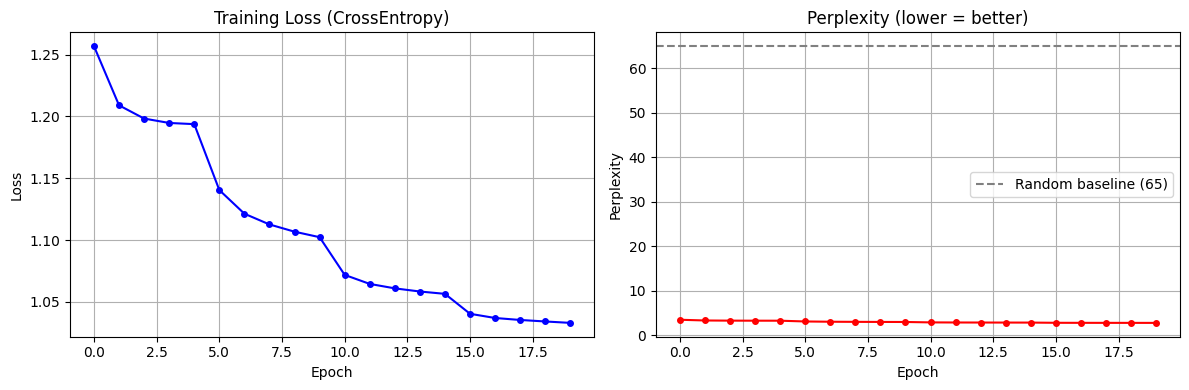

Final Loss: 1.0330  |  Final Perplexity: 2.81


In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['loss'], 'b-o', markersize=4)
axes[0].set_title('Training Loss (CrossEntropy)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True)

axes[1].plot([np.exp(l) for l in history['loss']], 'r-o', markersize=4)
axes[1].axhline(y=vocab_size, color='gray', linestyle='--', label=f'Random baseline ({vocab_size})')
axes[1].set_title('Perplexity (lower = better)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Perplexity')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
print(f'Final Loss: {history["loss"][-1]:.4f}  |  Final Perplexity: {np.exp(history["loss"][-1]):.2f}')

In [10]:
def generate_text(model, seed_text, num_chars=500, temperature=0.7):
    model.eval()
    generated = seed_text

    input_ids = torch.tensor(
        [[char2idx.get(c, 0) for c in seed_text]],
        dtype=torch.long
    ).to(device)

    hidden = model.init_hidden(1)

    with torch.no_grad():
        _, hidden = model(input_ids, hidden)

    last_char = torch.tensor([[char2idx.get(seed_text[-1], 0)]], dtype=torch.long).to(device)

    with torch.no_grad():
        for _ in range(num_chars):
            logits, hidden = model(last_char, hidden)
            logits = logits[0, 0] / temperature
            probs  = F.softmax(logits, dim=-1)
            next_id = torch.multinomial(probs, 1).item()
            next_ch = idx2char[next_id]
            generated += next_ch
            last_char = torch.tensor([[next_id]], dtype=torch.long).to(device)

    return generated

seeds = ['ROMEO:', 'To be, or', 'The king ']
temps = [0.3, 0.7, 1.0]

for seed in seeds:
    print(f'SEED: "{seed}"')
    for temp in temps:
        out = generate_text(model, seed, num_chars=300, temperature=temp)
        print(f'\n[ Temperature = {temp} ]')
        print(out)
    print()

SEED: "ROMEO:"

[ Temperature = 0.3 ]
ROMEO:
What are you all as most of this new stay?

Second Murderer:
What would you have thee so?

CORIOLANUS:
I know not what to be too much beloved,
And then begin to see them all again.

LADY CAPULET:
Well, sir, be not a strange but a dead man.

Second Murderer:
The words were such a person to the morni

[ Temperature = 0.7 ]
ROMEO:
We must not speak of me.
They were as perfect ministers to you.

KING RICHARD III:
Stand all advancement, set him upon their souls.

CLIFFORD:
Promise you, peace!

MERCUTIO:
He falls, when I do so, there is no better when
they have found indeed as is a bawd; for you
art strange in the people.

Firs

[ Temperature = 1.0 ]
ROMEO:
More than you, look you, all which being opes,
To raise him hither.

POLIXENES:
This is our abase and the thies well Barnardine!
His article is at love.

MENENIUS:
The king cannot proclaim.

SICINIUS:
Take my gracious lord.

GLOUCESTER:
Plantagenet: I would not be resign'd
I'st out of lips: awa

In [11]:
print('SPEAKER NAME PATTERNS')
for seed in ['HAM', 'OPH', 'CLA', 'HOR']:
    out = generate_text(model, seed, num_chars=80, temperature=0.5)
    print(f'  {out}')

print()

print('PHRASE COMPLETIONS')
for seed in ['What is ', 'I am ', 'Thou art ', 'My lord, ']:
    out = generate_text(model, seed, num_chars=100, temperature=0.6)
    print(f'  {out}')
    print()

print('LONG GENERATION (temperature=0.7)')
long_out = generate_text(model, 'HAMLET:\n', num_chars=800, temperature=0.7)
print(long_out)

SPEAKER NAME PATTERNS
  HAMISAO:
I have forgot the heavens be this infection.

KING RICHARD III:
Then, sir,
  OPHORSON:
I am a careful man in love.

Second Servant:
Or that I stand by me, and t
  CLADINE:
I thought I do remember well thou shalt be done:
But my noble cousin Bucki
  HORENCE:
Then when you can, I do not speak to the prince:
Therefore we may not spea

PHRASE COMPLETIONS
  What is the word?

MERCUTIO:
A lady he may say 'Thou art the court.

DUKE VINCENTIO:
The matter.

POLIXENES:

  I am on power.

CORIOLANUS:
No, sir.

CORIOLANUS:
The matter, you must know,
I do not like the part of th

  Thou art our time.

First Senator:
I am sure, sir.

SICINIUS:
A devil.

MENENIUS:
Now, by my brother.

MENENI

  My lord, are peril with the state.

KING RICHARD III:
But I will bite thee to the city in the world.

KING RI

LONG GENERATION (temperature=0.7)
HAMLET:
CORIOLANUS:
What! thou hast the daughter that the land shall show him
To the sea or our country.

CORIOLANUS:
So that the day

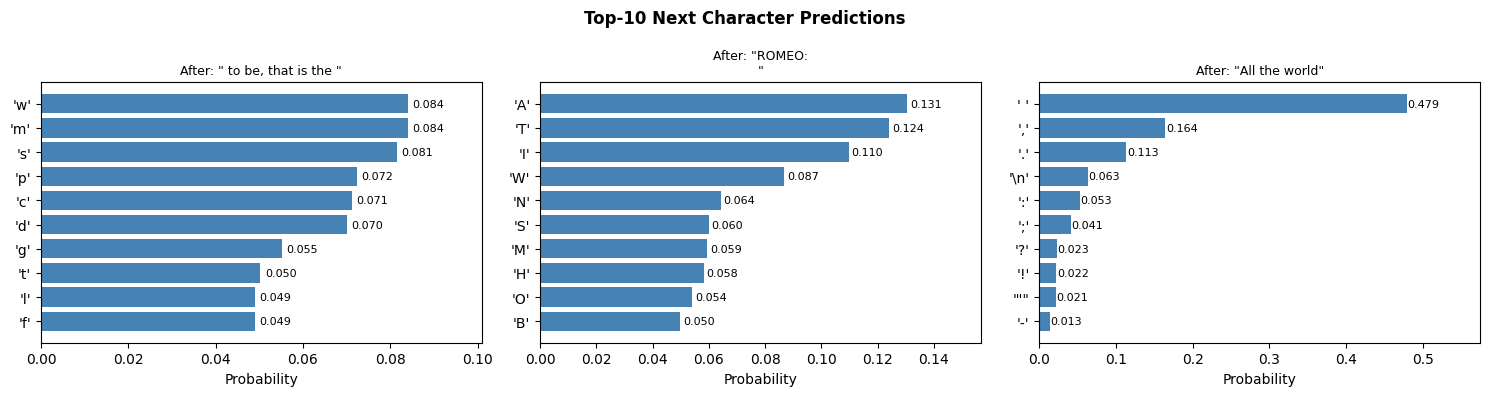

In [12]:
def get_top_predictions(model, context, top_k=10, temperature=1.0):
    model.eval()
    input_ids = torch.tensor(
        [[char2idx.get(c, 0) for c in context]],
        dtype=torch.long
    ).to(device)

    with torch.no_grad():
        logits, _ = model(input_ids)
        logits = logits[0, -1] / temperature
        probs  = F.softmax(logits, dim=-1).cpu().numpy()

    top_idx   = probs.argsort()[-top_k:][::-1]
    top_chars = [repr(idx2char[i]) for i in top_idx]
    top_probs = [probs[i] for i in top_idx]
    return top_chars, top_probs

contexts = [
    'To be, or not to be, that is the ',
    'ROMEO:\n',
    'All the world',
]

fig, axes = plt.subplots(1, len(contexts), figsize=(15, 4))

for ax, ctx in zip(axes, contexts):
    chars, probs = get_top_predictions(model, ctx, top_k=10)
    bars = ax.barh(chars[::-1], probs[::-1], color='steelblue')
    ax.set_title(f'After: "{ctx[-20:]}"', fontsize=9)
    ax.set_xlabel('Probability')
    ax.set_xlim(0, max(probs) * 1.2)
    for bar, p in zip(bars, probs[::-1]):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2, rf'{p:.3f}', va='center', fontsize=8)

plt.suptitle('Top-10 Next Character Predictions', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('prediction_confidence.png', dpi=150)
plt.show()